Loading libraries

In [51]:
import numpy as np
import pandas as pd
from helper_files.load_nifti_image import NiftiFile
import matplotlib.pyplot as plt
from scipy.spatial.distance import euclidean, cosine

Loading images and their masks for further use

In [ ]:
# CaSupp images
c_25_data = NiftiFile(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\myel_001_CaSupp_25.nii.gz").get_image_data()
c_50_data = NiftiFile(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\myel_001_CaSupp_50.nii.gz").get_image_data()
c_75_data = NiftiFile(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\myel_001_CaSupp_75.nii.gz").get_image_data()
c_100_data = NiftiFile(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\myel_001_CaSupp_100.nii.gz").get_image_data()

In [ ]:
# VMI images
vmi_40_data = NiftiFile(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\myel_001_monoe_40kev.nii.gz").get_image_data()
vmi_80_data = NiftiFile(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\myel_001_monoe_80kev.nii.gz").get_image_data()
vmi_120_data = NiftiFile(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\myel_001_monoe_120kev.nii.gz").get_image_data()

In [ ]:
# Vertebrae and lesions mask
vertebrae_data = NiftiFile(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\myel_001_spine_seg_nnUNet_cor.nii.gz").get_image_data()
lesions_data = NiftiFile(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\Myel_001_lesions_seg_validation_VV_final.nii.gz").get_image_data()

In [ ]:
# Calculate RMS for healthy vertebrae in whole spine
print("RMS (Contrast) in just healthy vertebrae")
print(f"C_25: {np.sqrt(np.mean((c_25_data[(vertebrae_data > 0) & (lesions_data == 0)]) ** 2))}")
print(f"C_50: {np.sqrt(np.mean((c_50_data[(vertebrae_data > 0) & (lesions_data == 0)]) ** 2))}")
print(f"C_75: {np.sqrt(np.mean((c_75_data[(vertebrae_data > 0) & (lesions_data == 0)]) ** 2))}")
print(f"C_100: {np.sqrt(np.mean((c_100_data[(vertebrae_data > 0) & (lesions_data == 0)]) ** 2))}")
print()
print(f"VMI_40: {np.sqrt(np.mean((vmi_40_data[(vertebrae_data > 0) & (lesions_data == 0)]) ** 2))}")
print(f"VMI_80: {np.sqrt(np.mean((vmi_80_data[(vertebrae_data > 0) & (lesions_data == 0)]) ** 2))}")
print(f"VMI_120: {np.sqrt(np.mean((vmi_120_data[(vertebrae_data > 0) & (lesions_data == 0)]) ** 2))}")

In [ ]:
# Calculate RMS for lesions in whole spine
print("RMS (Contrast) in just lesions")
print(f"C_25: {np.sqrt(np.mean((c_25_data[(lesions_data > 0)]) ** 2))}")
print(f"C_50: {np.sqrt(np.mean((c_50_data[(lesions_data > 0)]) ** 2))}")
print(f"C_75: {np.sqrt(np.mean((c_75_data[(lesions_data > 0)]) ** 2))}")
print(f"C_100: {np.sqrt(np.mean((c_100_data[(lesions_data > 0)]) ** 2))}")
print()
print(f"VMI_40: {np.sqrt(np.mean((vmi_40_data[(lesions_data > 0)]) ** 2))}")
print(f"VMI_80: {np.sqrt(np.mean((vmi_80_data[(lesions_data > 0)]) ** 2))}")
print(f"VMI_120: {np.sqrt(np.mean((vmi_120_data[(lesions_data > 0)]) ** 2))}")

In [ ]:
# Calculate RMS for vertebrae (healthy and also lesions) in whole spine
print("RMS (Contrast) in vertebrae (healthy+lesions)")
print(f"C_25: {np.sqrt(np.mean((c_25_data[(vertebrae_data > 0)]) ** 2))}")
print(f"C_50: {np.sqrt(np.mean((c_50_data[(vertebrae_data > 0)]) ** 2))}")
print(f"C_75: {np.sqrt(np.mean((c_75_data[(vertebrae_data > 0)]) ** 2))}")
print(f"C_100: {np.sqrt(np.mean((c_100_data[(vertebrae_data > 0)]) ** 2))}")
print()
print(f"VMI_40: {np.sqrt(np.mean((vmi_40_data[(vertebrae_data > 0)]) ** 2))}")
print(f"VMI_80: {np.sqrt(np.mean((vmi_80_data[(vertebrae_data > 0)]) ** 2))}")
print(f"VMI_120: {np.sqrt(np.mean((vmi_120_data[(vertebrae_data > 0)]) ** 2))}")

Visualization of RMS in different type of images

In [ ]:
# Example data (you can replace these with your actual 3 outputs)
data_healthy_vertebrae = {
    "C_25": np.sqrt(np.mean((c_25_data[(vertebrae_data > 0) & (lesions_data == 0)]) ** 2)),
    "C_50": np.sqrt(np.mean((c_50_data[(vertebrae_data > 0) & (lesions_data == 0)]) ** 2)),
    "C_75": np.sqrt(np.mean((c_75_data[(vertebrae_data > 0) & (lesions_data == 0)]) ** 2)),
    "C_100": np.sqrt(np.mean((c_100_data[(vertebrae_data > 0) & (lesions_data == 0)]) ** 2)),
    "VMI_40": np.sqrt(np.mean((vmi_40_data[(vertebrae_data > 0) & (lesions_data == 0)]) ** 2)),
    "VMI_80": np.sqrt(np.mean((vmi_80_data[(vertebrae_data > 0) & (lesions_data == 0)]) ** 2)),
    "VMI_120": np.sqrt(np.mean((vmi_120_data[(vertebrae_data > 0) & (lesions_data == 0)]) ** 2))
}

data_lesions = {
    "C_25": np.sqrt(np.mean((c_25_data[(lesions_data > 0)]) ** 2)),
    "C_50": np.sqrt(np.mean((c_50_data[(lesions_data > 0)]) ** 2)),
    "C_75": np.sqrt(np.mean((c_75_data[(lesions_data > 0)]) ** 2)),
    "C_100": np.sqrt(np.mean((c_100_data[(lesions_data > 0)]) ** 2)),
    "VMI_40": np.sqrt(np.mean((vmi_40_data[(lesions_data > 0)]) ** 2)),
    "VMI_80": np.sqrt(np.mean((vmi_80_data[(lesions_data > 0)]) ** 2)),
    "VMI_120": np.sqrt(np.mean((vmi_120_data[(lesions_data > 0)]) ** 2))
}

data_whole_vertebrae = {
    "C_25": np.sqrt(np.mean((c_25_data[(vertebrae_data > 0)]) ** 2)),
    "C_50": np.sqrt(np.mean((c_50_data[(vertebrae_data > 0)]) ** 2)),
    "C_75": np.sqrt(np.mean((c_75_data[(vertebrae_data > 0)]) ** 2)),
    "C_100": np.sqrt(np.mean((c_100_data[(vertebrae_data > 0)]) ** 2)),
    "VMI_40": np.sqrt(np.mean((vmi_40_data[(vertebrae_data > 0)]) ** 2)),
    "VMI_80": np.sqrt(np.mean((vmi_80_data[(vertebrae_data > 0)]) ** 2)),
    "VMI_120": np.sqrt(np.mean((vmi_120_data[(vertebrae_data > 0)]) ** 2))
}

# Consistent x-axis
keys = list(data_healthy_vertebrae.keys())

# Create subplots (3 rows, 1 column)
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# Healthy vertebra ---
axes[0].plot(keys, list(data_healthy_vertebrae.values()), marker='o', color='blue')
axes[0].set_title("Just Healthy Vertebrae")
axes[0].grid(True, linestyle="--", alpha=0.5)

# Lesions
axes[1].plot(keys, list(data_lesions.values()), marker='o', color='red')
axes[1].set_title("Just Lesions")
axes[1].grid(True, linestyle="--", alpha=0.5)

# Whole vertebrae (including lesions)
axes[2].plot(keys, list(data_whole_vertebrae.values()), marker='o', color='green')
axes[2].set_title("All Vertebrae Including Lesions")
axes[2].grid(True, linestyle="--", alpha=0.5)

# Common labels
fig.suptitle("Comparison of Contrast (RMS) Values", fontsize=14)
axes[2].set_xlabel("Image")
for ax in axes:
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()


Compute differences between different image types (CaSupp/VMI) -> from each group pick the best one

In [89]:
# Load csv - spine lesions
c25_l = pd.read_csv(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\CaSupp_25_radiomics_spine_lesions_features.csv")
c50_l = pd.read_csv(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\CaSupp_50_radiomics_spine_lesions_features.csv")
c75_l = pd.read_csv(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\CaSupp_75_radiomics_spine_lesions_features.csv")
c100_l = pd.read_csv(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\CaSupp_100_radiomics_spine_lesions_features.csv")

vmi40_l = pd.read_csv(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\monoe_40kev_radiomics_spine_lesions_features.csv")
vmi80_l = pd.read_csv(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\monoe_80kev_radiomics_spine_lesions_features.csv")
vmi120_l = pd.read_csv(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\monoe_120kev_radiomics_spine_lesions_features.csv")


# Load csv - spine vertebrae
c25_v = pd.read_csv(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\CaSupp_25_radiomics_spine_vertebrae_features.csv")
c50_v = pd.read_csv(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\CaSupp_50_radiomics_spine_vertebrae_features.csv")
c75_v = pd.read_csv(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\CaSupp_75_radiomics_spine_vertebrae_features.csv")
c100_v = pd.read_csv(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\CaSupp_100_radiomics_spine_vertebrae_features.csv")

vmi40_v = pd.read_csv(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\monoe_40kev_radiomics_spine_vertebrae_features.csv")
vmi80_v = pd.read_csv(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\monoe_80kev_radiomics_spine_vertebrae_features.csv")
vmi120_v = pd.read_csv(r"C:\Users\lukas\OneDrive - VUT\Plocha\Diploma thesis\Myel_001\monoe_120kev_radiomics_spine_vertebrae_features.csv")

In [91]:
# Drop number of lesions (useless for this purpose)
for df in [c25_l, c50_l, c75_l, c100_l, vmi40_l, vmi80_l, vmi120_l]:
    df = df.drop(columns=["n_lesions"], inplace=True)

In [90]:
# Compute volume of lesions and vertebrae for standardization
l_volume = float(c25_l["original_shape_VoxelVolume"].iloc[0])
v_volume = float(c25_v["original_shape_VoxelVolume"].iloc[0])
print(l_volume, v_volume)

3782.791649484807 960227.7267765658


In [92]:
# Compute distance metrics (Euclidian, Cosine) - NO STANDARDIZATION
dfs_l = [c25_l, c50_l, c75_l, c100_l, vmi40_l, vmi80_l, vmi120_l]
dfs_v = [c25_v, c50_v, c75_v, c100_v, vmi40_v, vmi80_v, vmi120_v]
names = ["c25", "c50", "c75", "c100", "vmi40", "vmi80", "vmi120"]

eucl_distances = []
cos_distances = []

for l, v, name in zip(dfs_l, dfs_v, names):
    e_dist = euclidean(np.array(l.iloc[0]), np.array(v.iloc[0]))
    c_dist = cosine(np.array(l.iloc[0]), np.array(v.iloc[0]))
    eucl_distances.append(e_dist)
    cos_distances.append(c_dist)

In [93]:
# Compute distance metrics (Euclidian, Cosine) - STANDARDIZATION
dfs_l = [c25_l/l_volume, c50_l/l_volume, c75_l/l_volume, c100_l/l_volume, vmi40_l/l_volume, vmi80_l/l_volume, vmi120_l/l_volume]
dfs_v = [c25_v/v_volume, c50_v/v_volume, c75_v/v_volume, c100_v/v_volume, vmi40_v/v_volume, vmi80_v/v_volume, vmi120_v/v_volume]
names = ["c25", "c50", "c75", "c100", "vmi40", "vmi80", "vmi120"]

eucl_distances = []
cos_distances = []

for l, v, name in zip(dfs_l, dfs_v, names):
    e_dist = euclidean(np.array(l.iloc[0]), np.array(v.iloc[0]))
    c_dist = cosine(np.array(l.iloc[0]), np.array(v.iloc[0]))
    eucl_distances.append(e_dist)
    cos_distances.append(c_dist)

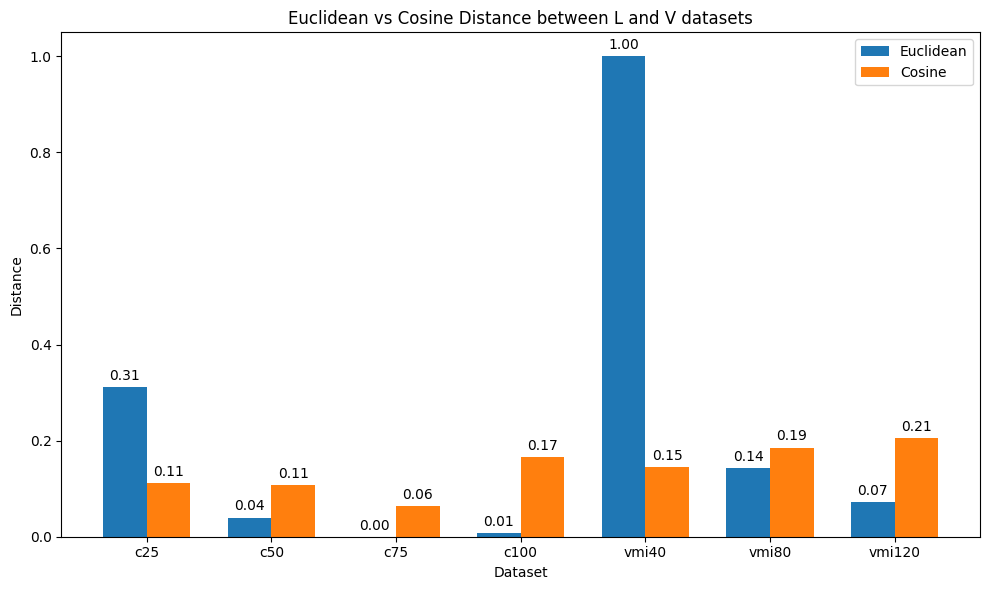

In [88]:
# VISUALIZATION
# Normalize Euclidean distances (0-1)
eucl_distances = np.array(eucl_distances)
eucl_norm = (eucl_distances - eucl_distances.min()) / (eucl_distances.max() - eucl_distances.min())

x = np.arange(len(names))  # positions for bars
width = 0.35  # width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

# Bar for Euclidean
rects1 = ax.bar(x - width/2, eucl_norm, width, label='Euclidean')

# Bar for Cosine
rects2 = ax.bar(x + width/2, cos_distances, width, label='Cosine')

# Labels and title
ax.set_ylabel('Distance')
ax.set_xlabel('Dataset')
ax.set_title('Euclidean vs Cosine Distance between L and V datasets')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.legend()

# Optional: Add values on top of bars
for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()